In [1]:
import numpy as np
import sys
from pathlib import Path

sys.path.append('../code/')

from mlalgos import HyperOpt
from mllib import Utilities,MLUtilities

from time import time
import copy,pickle

import matplotlib.pyplot as plt
from matplotlib import gridspec
import matplotlib as mpl
import matplotlib.colors as pltcol
import gc

import tensorflow as tf

ut = Utilities()
ml = MLUtilities()

I0000 00:00:1787414423.068181   20868 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787414423.068773   20868 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1787414423.104190   20868 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1787414423.942997   20868 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

In [2]:
mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['ytick.direction'] = 'in'
mpl.rcParams['xtick.top'] = True
mpl.rcParams['ytick.right'] = True
mpl.rcParams['xtick.labelsize'] = 14
mpl.rcParams['ytick.labelsize'] = 14
mpl.rcParams['axes.labelsize'] = 16
mpl.rcParams['legend.fontsize'] = 14 # 14
mpl.rcParams['legend.labelspacing'] = 0.25
FS = 18
FS2 = 15
FS3 = 14
FSS = 12
FSL = 22

mpl.rcParams['xtick.major.size'] = 6
mpl.rcParams['xtick.minor.size'] = 3
mpl.rcParams['ytick.major.size'] = 6
mpl.rcParams['ytick.minor.size'] = 3

#mpl.rcParams.keys()

# Example usage of AutoEncoder  
### using shallow networks with `HyperOpt` for optimization

In [14]:
Out_Stem = 'autoencoder/'

Plot_Stem = Out_Stem + 'plots'
Path(Plot_Stem).mkdir(parents=True,exist_ok=True)

Nproc = 4 # large mem reqs for MNIST mean 1 is best

Save_Fig = True

In [24]:
Depth_Str = 'shallow'
Plot_Str = '' + Depth_Str

Family = 'autoenc'

## Regression example: MNIST

### Data setup

In [16]:
Vortex = True     # 'vortex unroll' to partially preserve spatial coherence in flattened array
Downsample = 0.01  # 1.0 is doable on desktop: reaches ~59.6GB RAM using N = 3 x 48 jobs, scales ~ 1/N
K = 10

In [17]:
start_time = time()
(X_train_tf, Y_train_tf), (X_test_tf, Y_test_tf) = tf.keras.datasets.mnist.load_data()

print(X_train_tf.shape,X_test_tf.shape)

if Vortex:
    print('... vortex unroll')
    X_train = ml.vortex_package(X_train_tf.T).astype(float) # (784,nsamp)
    X_test = ml.vortex_package(X_test_tf.T).astype(float) # (784,nsamp)
else:
    print('... standard flatten')
    X_train = np.zeros((X_train_tf.shape[0],X_train_tf.shape[1]**2))
    for i in range(X_train_tf.shape[0]):
        X_train[i] = X_train_tf[i].flatten()
    X_train = X_train.T
    
    X_test = np.zeros((X_test_tf.shape[0],X_test_tf.shape[1]**2))
    for i in range(X_test_tf.shape[0]):
        X_test[i] = X_test_tf[i].flatten()
    X_test = X_test.T

# don't standardize here, use 'standardize_X' instead
# X_train /= 255.0
# X_test /= 255.0

del X_train_tf,Y_train_tf
del X_test_tf,Y_test_tf
gc.collect()

print(X_train.shape,X_test.shape)

rng = np.random.RandomState(1991)

n_test = X_test.shape[1]
if Downsample is None:
    print('... no downsampling')
    n_train = X_train.shape[1]
else:
    print('... downsampling by factor {0:.3f}'.format(Downsample))
    n_train = int(Downsample*X_train.shape[1])
    ind_train = rng.choice(X_train.shape[1],size=n_train,replace=False)
    X_train = X_train[:,ind_train]
    del ind_train
    
    # comment below 4 to use full test set
    n_test = int(Downsample*X_test.shape[1])  
    ind_test = rng.choice(X_test.shape[1],size=n_test,replace=False)
    X_test = X_test[:,ind_test]
    del ind_test

    gc.collect()

    print('... retained {0:d} training and {1:d} testing samples'.format(n_train,n_test))

print('... shuffling')
ind_shuff_train = rng.choice(n_train,size=n_train,replace=False)
X_train = X_train[:,ind_shuff_train]

ind_shuff_test = rng.choice(n_test,size=n_test,replace=False)
X_test = X_test[:,ind_shuff_test]

del ind_shuff_train,ind_shuff_test
gc.collect()

print('... done')
ut.time_this(start_time)

(60000, 28, 28) (10000, 28, 28)
... vortex unroll
(784, 60000) (784, 10000)
... downsampling by factor 0.010
... retained 600 training and 100 testing samples
... shuffling
... done
0 min 2.17 seconds



### Network setup and training

In [25]:
# dictionary containing all setup parameters and data
setup_dict = {} 

# -- data set: features and labels
setup_dict['X'] = X_train

# -- network family and auxiliary params
setup_dict['family'] = 'autoenc'
setup_dict['denoise'] = False
setup_dict['noise_level'] = 0.1 

Out_Dir = Out_Stem + ('baseline/' if not setup_dict['denoise'] else 'denoise{0:.2f}/'.format(setup_dict['noise_level']))
print('output dir:',Out_Dir)

File_Stem = Out_Dir + 'ae'
print('File_Stem:',File_Stem)

# # -- curriculum
# setup_dict['curriculum'] = None # will be changed below

# -- training sample 
setup_dict['train_frac'] = 0.8
setup_dict['val_frac'] = 0.2
setup_dict['loss_type'] = 'square'
setup_dict['neg_labels'] = False 

# -- training setup
setup_dict['standardize_X'] = True
setup_dict['max_epoch'] = 54
setup_dict['check_after'] = 54 
setup_dict['seed'] = None
setup_dict['test_type'] = 'mse' # 'perc' or 'mse'
setup_dict['file_stem'] = File_Stem

#-----------------------
# total number of networks trained will be n_iter * max_config
N_Iter = 2 
Max_Config = 6#0
setup_dict['n_iter'] = N_Iter
setup_dict['max_config'] = Max_Config
#-----------------------

setup_dict['ensemble'] = False 
# setup_dict['ensemble_size'] = 5

setup_dict['nproc'] = np.min([Nproc,N_Iter*Max_Config])
setup_dict['fixed_width'] = None # would also have been set internally
setup_dict['fixed_htype'] = False

# -- sampled parameters
setup_dict['layers'] = {'min':3,'max':4}
setup_dict['widths'] = {'min':9,'max':11} # bottleneck layer range
setup_dict['lglrates'] = {'min':-3.5,'max':-2.0}
setup_dict['wt_decays'] = {'min':0.0,'max':0.1}
setup_dict['htypes'] = ['tanh','splus','relu','lrelu','sin']
setup_dict['lrelu_slopes'] = {'min':-1e-2,'max':1e-2}
setup_dict['reg_funs'] = ['drop','bn','none'] 
setup_dict['p_drops'] = {'min':0.0,'max':0.5}

# -- I/O
setup_dict['verbose'] = True
setup_dict['logfile'] = None

# # -- storage for ensemble-averaged count of weights in NEO
# Avg_Wts = {}

output dir: autoencoder/baseline/
File_Stem: autoencoder/baseline/ae


#### Training

In [26]:
Optimize = True

start_time = time()
hopt = HyperOpt(setup_dict=setup_dict)

if Optimize:
    ae,ptrain,bts = hopt.optimize()
else:
    ae = hopt.load()
    ptrain,bts = hopt.load_train()

ut.time_this(start_time)

# Avg_Wts['curr'] = neo_curr.display_summary(show_keys=['L','wt_decay','n_layer','atypes','reg_fun','threshold'],
#                                            train_keys=['lrate','slowdown'],
#                                            return_avg_wts=True)

--------------
Hyperparameter + architecture optimization
--------------
... neural network family: AutoEncoder
... ... standard training will be implemented
... found data set of dimension 784 with targets of dimension 784
... found 600 samples
... fraction 0.800 (480 samples) will be used for training
... will search over 2 iterations of 6 configurations
... will use mean squared error for hyperparameter comparison
... weight decays will use norm 2
... setup complete
Initiating search... 
... setting tasks
... training using 4 process(es)
[....................] 100% done

... identifying and saving best network and its teststat and training params
1 min 52.77 seconds



Best test stat = 6.042e+01
Setup params:
... L: 8
... wt_decay: 0.016666666666666666
... n_layer: [119, 39, 18, 10, 18, 39, 119, 784]
... atypes: [np.str_('splus'), np.str_('lrelu'), np.str_('splus'), np.str_('sin'), np.str_('sin'), np.str_('splus'), np.str_('splus'), 'lin']
... ... lrelu_slope: -6.67e-03
... check_after: 54
... lrate: 5.62e-04
No. of free params optimized = 198784



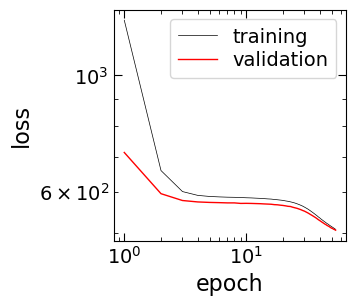

In [27]:
show_keys = ['L','wt_decay','n_layer','atypes']

print('Best test stat = {0:.3e}'.format(bts))
print('Setup params:')
for pkey in show_keys:
    print('... '+pkey+':',ae.params[pkey])
    if pkey == 'atypes':
        if 'lrelu' in ae.params[pkey]:
            print('... ... lrelu_slope: {0:.2e}'.format(ae.params['lrelu_slope']))
print('... check_after: {0:d}'.format(ptrain['check_after']))
print('... lrate: {0:.2e}'.format(ptrain['lrate']))

N_free_std = ae.net.calc_N_freeparams()
print('No. of free params optimized = {0:d}\n'.format(N_free_std))

plt.figure(figsize=(3,3))
plt.yscale('log')
plt.xscale('log')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.plot(ae.net.epochs,ae.net.training_loss,'k-',lw=0.5,label='training')
plt.plot(ae.net.epochs,ae.net.val_loss,'r-',lw=1,label='validation')
plt.legend()
plt.show()
